# Content preservation, take 2 — attention alone, no copy mechanism

`05_content_preservation_experiment.ipynb` bundled five changes together and found that content preservation F1 jumped from 0.25 to 0.91 - but it was a hollow win: the copy/pointer mechanism let the model discover a trivial "attend to my own same-index source position and echo it" shortcut (this is an autoencoder, so the reconstruction target *is* the source recipe, unlike typical pointer-generator setups where source and target differ). Transfer strength collapsed from 0.96 to 0.03 as a result - the model mostly stopped transferring style at all.

This notebook isolates the other four changes, which were never tested on their own because the copy mechanism dominated the previous run's outcome:

1. **Attention** over per-timestep encoder content-states — kept.
2. ~~A copy/pointer mechanism~~ — **removed**. Back to a standard generation-only decoder (attention context feeds the vocabulary softmax, nothing more).
3. **A bigger content latent** (`hidden_dim` 512 → 768, content_dim 448 → 704) — kept.
4. **Retuned adversarial loss weight** (2.0 → 1.0) — kept.
5. **Teacher-forcing decay** (fixed 0.5 → linear 0.9 → 0.1) — kept.

Same evaluation protocol as before: the original best checkpoint is reloaded and freshly re-scored (same held-out sample, same independent eval classifier) for a fair before/after comparison. Entirely separate checkpoint/artifact filenames from both `02_model.ipynb` and `05_content_preservation_experiment.ipynb` - nothing from either is touched.

## Load the preprocessed artifacts (same as `02_model.ipynb` / `05_...ipynb`)

In [1]:
import ast
import os

import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from gensim.models import KeyedVectors
from torch.utils.data import Dataset, DataLoader

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

def load_split(name):
    df = pd.read_csv(f'./data/recipes_{name}.csv', index_col=0)
    df['steps_tokens'] = df['steps_tokens'].apply(ast.literal_eval)
    df['steps_tokens_bow'] = df['steps_tokens_bow'].apply(ast.literal_eval)
    return df

train_df = load_split('train')
val_df = load_split('val')
test_df = load_split('test')

df_final = pd.read_csv('./data/recipes_final.csv', index_col=0)[['name', 'steps']]

wv = KeyedVectors.load('./data/models/word2vec.wordvectors')

def identity_analyzer(tokens):
    return tokens

vectorizer = joblib.load('./data/models/bow_vectorizer.joblib')

X_train_bow = vectorizer.transform(train_df['steps_tokens_bow'])
X_val_bow = vectorizer.transform(val_df['steps_tokens_bow'])
X_test_bow = vectorizer.transform(test_df['steps_tokens_bow'])

print(train_df.shape, val_df.shape, test_df.shape)

mps
(8637, 3) (1851, 3) (1851, 3)


In [2]:
seq_len = int(train_df['steps_tokens'].apply(len).quantile(0.95))
input_dim = wv.vector_size
print('seq_len:', seq_len, '| input_dim:', input_dim)

def tokens_to_matrix(tokens, wv, seq_len):
    matrix = np.zeros((seq_len, wv.vector_size), dtype=np.float32)
    for i, token in enumerate(tokens[:seq_len]):
        if token in wv:
            matrix[i] = wv[token]
    return matrix

PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN = '<PAD>', '<UNK>', '<SOS>', '<EOS>'
word2idx = dict(wv.key_to_index)
word2idx[PAD_TOKEN] = len(word2idx)
PAD_IDX = word2idx[PAD_TOKEN]
word2idx[UNK_TOKEN] = len(word2idx)
UNK_IDX = word2idx[UNK_TOKEN]
word2idx[SOS_TOKEN] = len(word2idx)
SOS_IDX = word2idx[SOS_TOKEN]
word2idx[EOS_TOKEN] = len(word2idx)
EOS_IDX = word2idx[EOS_TOKEN]
VOCAB_SIZE = len(word2idx)
idx2word = {idx: word for word, idx in word2idx.items()}

def tokens_to_indices(tokens, word2idx, seq_len):
    tokens = tokens[:seq_len - 1]
    indices = [word2idx.get(t, UNK_IDX) for t in tokens]
    indices.append(EOS_IDX)
    indices += [PAD_IDX] * (seq_len - len(indices))
    return indices

def indices_to_tokens(indices):
    tokens = []
    for i in indices:
        if i == EOS_IDX:
            break
        if i != PAD_IDX:
            tokens.append(idx2word[i])
    return tokens

CUISINE2IDX = {'Italian': 0, 'Indian': 1}
IDX2CUISINE = {idx: name for name, idx in CUISINE2IDX.items()}
BOW_VOCAB_SIZE = X_train_bow.shape[1]
NO_REPEAT_NGRAM_SIZE = 3

seq_len: 223 | input_dim: 150


In [3]:
class RecipeDataset(Dataset):
    def __init__(self, df, wv, word2idx, seq_len, cuisine2idx, bow_matrix):
        self.tokens = df['steps_tokens'].tolist()
        self.cuisines = df['cuisine'].tolist()
        self.wv = wv
        self.word2idx = word2idx
        self.seq_len = seq_len
        self.cuisine2idx = cuisine2idx
        self.bow_matrix = bow_matrix

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):
        tokens = self.tokens[idx]
        x = tokens_to_matrix(tokens, self.wv, self.seq_len)
        y = tokens_to_indices(tokens, self.word2idx, self.seq_len)
        length = max(1, min(len(tokens), self.seq_len))
        style_label = self.cuisine2idx[self.cuisines[idx]]
        bow_target = (self.bow_matrix[idx].toarray().ravel() > 0).astype(np.float32)
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
            torch.tensor(style_label, dtype=torch.long),
            torch.tensor(bow_target, dtype=torch.float32),
        )

BATCH_SIZE = 32
train_dataset = RecipeDataset(train_df, wv, word2idx, seq_len, CUISINE2IDX, X_train_bow)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataset = RecipeDataset(val_df, wv, word2idx, seq_len, CUISINE2IDX, X_val_bow)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_dataset = RecipeDataset(test_df, wv, word2idx, seq_len, CUISINE2IDX, X_test_bow)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

## Attention-ready encoder with a bigger content latent (unchanged from `05_...ipynb`)

Still returns per-timestep content-projected states for attention, and still uses `hidden_dim=768` (content_dim 704) instead of the baseline's 512 (content_dim 448).

In [4]:
class GRUEncoderAttn(nn.Module):
    def __init__(self, input_dim, hidden_dim, style_dim, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.style_dim = style_dim
        self.content_dim = hidden_dim - style_dim
        self.style_head = nn.Linear(hidden_dim, style_dim)
        self.content_head = nn.Linear(hidden_dim, self.content_dim)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, hidden = self.gru(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=x.size(1))
        outputs = self.dropout(outputs)
        hidden = hidden.squeeze(0)
        hidden = self.dropout(hidden)
        style_latent = self.style_head(hidden)
        content_latent = self.content_head(hidden)
        content_states = self.content_head(outputs)
        return style_latent, content_latent, content_states

hidden_dim = 768
STYLE_DIM = 64
encoder = GRUEncoderAttn(input_dim, hidden_dim, STYLE_DIM, dropout=0.2).to(device)
print('content_dim:', encoder.content_dim, '(was 448 in the baseline model)')

content_dim: 704 (was 448 in the baseline model)


## Attention decoder — **no copy mechanism this time**

Same attention scoring as `05_...ipynb` (project `content_states` once, dot-product against the current GRU hidden state, softmax, weighted-sum context vector), but the context now only feeds the vocabulary generation layer - there's no `p_gen` gate, no scatter-add copy distribution, no probability-space mixing. Output goes back to being raw logits, so the loss goes back to plain `CrossEntropyLoss` - exactly like the original `GRUDecoder`, just with an attention context concatenated in.

In [5]:
def block_repeat_ngrams(logits_t, generated, ngram_size):
    for b in range(logits_t.size(0)):
        seq = generated[b]
        if seq:
            logits_t[b, seq[-1]] = float('-inf')
        if len(seq) < ngram_size - 1:
            continue
        prefix = tuple(seq[-(ngram_size - 1):])
        banned = {seq[i + ngram_size - 1] for i in range(len(seq) - ngram_size + 1) if tuple(seq[i:i + ngram_size - 1]) == prefix}
        if banned:
            logits_t[b, list(banned)] = float('-inf')
    return logits_t

class AttnGRUDecoder(nn.Module):
    def __init__(self, hidden_dim, content_dim, vocab_size, embed_dim, sos_idx, pad_idx, unk_idx, max_len, dropout=0.2):
        super().__init__()
        self.max_len = max_len
        self.sos_idx = sos_idx
        self.unk_idx = unk_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.gru_cell = nn.GRUCell(embed_dim, hidden_dim)
        self.attn_proj = nn.Linear(content_dim, hidden_dim, bias=False)
        self.fc_out = nn.Linear(hidden_dim + content_dim, vocab_size)

    def forward(self, hidden, content_states, mask, target=None, teacher_forcing_ratio=0.5, no_repeat_ngram_size=0):
        batch_size = hidden.size(0)
        device = hidden.device
        max_len = target.size(1) if target is not None else self.max_len

        projected_states = self.attn_proj(content_states)   # precomputed once, doesn't change across decode steps
        neg_inf_mask = (~mask).float() * -1e9

        input_idx = torch.full((batch_size,), self.sos_idx, dtype=torch.long, device=device)
        h = hidden
        outputs = []
        generated = [[] for _ in range(batch_size)] if no_repeat_ngram_size > 0 else None

        for t in range(max_len):
            embedded = self.embedding(input_idx)
            embedded = self.dropout(embedded)
            h = self.gru_cell(embedded, h)

            scores = torch.bmm(projected_states, h.unsqueeze(-1)).squeeze(-1) + neg_inf_mask
            attn_weights = torch.softmax(scores, dim=-1)
            context = torch.bmm(attn_weights.unsqueeze(1), content_states).squeeze(1)

            logits_t = self.fc_out(torch.cat([h, context], dim=-1))

            use_teacher_forcing = target is not None and torch.rand(1).item() < teacher_forcing_ratio
            if use_teacher_forcing:
                outputs.append(logits_t.unsqueeze(1))
                input_idx = target[:, t]
            else:
                if target is None:
                    logits_t = logits_t.clone()
                    logits_t[:, self.unk_idx] = float('-inf')
                    if no_repeat_ngram_size > 0:
                        logits_t = block_repeat_ngrams(logits_t, generated, no_repeat_ngram_size)
                outputs.append(logits_t.unsqueeze(1))
                input_idx = logits_t.argmax(dim=-1)
                if no_repeat_ngram_size > 0 and target is None:
                    for b in range(batch_size):
                        generated[b].append(input_idx[b].item())

        return torch.cat(outputs, dim=1)  # (batch, max_len, vocab_size) logits - not log-probs

decoder = AttnGRUDecoder(
    hidden_dim, encoder.content_dim, VOCAB_SIZE, input_dim, SOS_IDX, PAD_IDX, UNK_IDX, seq_len, dropout=0.2
).to(device)

## Combined autoencoder wrapper (no `source_ids` needed - there's nothing to copy from)

In [6]:
class Seq2SeqAutoencoderAttnNoCopy(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x, lengths, target=None, teacher_forcing_ratio=0.5, no_repeat_ngram_size=0, return_latents=False):
        style_latent, content_latent, content_states = self.encoder(x, lengths)
        seq_len_ = content_states.size(1)
        mask_len = lengths.clamp(max=seq_len_).to(content_states.device)
        mask = torch.arange(seq_len_, device=content_states.device).unsqueeze(0) < mask_len.unsqueeze(1)
        hidden0 = torch.cat([style_latent, content_latent], dim=-1)
        logits = self.decoder(
            hidden0, content_states, mask, target=target,
            teacher_forcing_ratio=teacher_forcing_ratio, no_repeat_ngram_size=no_repeat_ngram_size,
        )
        if return_latents:
            return logits, style_latent, content_latent
        return logits

model = Seq2SeqAutoencoderAttnNoCopy(encoder, decoder).to(device)

## Classifiers + retuned adversarial weight (unchanged from `05_...ipynb`)

In [7]:
style_classifier = nn.Linear(STYLE_DIM, len(CUISINE2IDX)).to(device)
content_classifier = nn.Sequential(
    nn.Linear(encoder.content_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, BOW_VOCAB_SIZE)
).to(device)
adv_style_classifier = nn.Sequential(
    nn.Linear(encoder.content_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, len(CUISINE2IDX))
).to(device)
adv_content_classifier = nn.Sequential(
    nn.Linear(encoder.style_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, BOW_VOCAB_SIZE)
).to(device)

recon_criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)  # back to plain logits, no copy mixing
style_criterion = nn.CrossEntropyLoss()
content_criterion = nn.BCEWithLogitsLoss()
adv_style_criterion = nn.CrossEntropyLoss()
adv_content_criterion = nn.BCEWithLogitsLoss()

def categorical_entropy(logits):
    log_probs = torch.log_softmax(logits, dim=-1)
    return -(log_probs.exp() * log_probs).sum(dim=-1).mean()

def bernoulli_entropy(logits):
    log_p = F.logsigmoid(logits)
    log_1m_p = F.logsigmoid(-logits)
    p = log_p.exp()
    return -(p * log_p + (1 - p) * log_1m_p).mean(dim=-1).mean()

optimizer = torch.optim.Adam(
    list(model.parameters()) + list(style_classifier.parameters()) + list(content_classifier.parameters()),
    lr=1e-3, weight_decay=1e-5,
)
adv_style_optimizer = torch.optim.RMSprop(adv_style_classifier.parameters(), lr=1e-3)
adv_content_optimizer = torch.optim.RMSprop(adv_content_classifier.parameters(), lr=1e-3)

@torch.no_grad()
def evaluate_val_recon_loss_attn(model, val_loader, device):
    was_training = model.training
    model.eval()
    total = 0.0
    for batch_x, batch_y, batch_len, _, _ in val_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        logits = model(batch_x, batch_len, target=batch_y, teacher_forcing_ratio=0.0)
        total += recon_criterion(logits.permute(0, 2, 1), batch_y).item()
    if was_training:
        model.train()
    return total / len(val_loader)

CHECKPOINT_PATH = './data/models/checkpoint_attn_nocopy.pt'
BEST_RECON_CHECKPOINT_PATH = './data/models/checkpoint_attn_nocopy_best_recon.pt'
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)

def make_checkpoint(epoch, best_recon_loss):
    return {
        'epoch': epoch,
        'best_recon_loss': best_recon_loss,
        'model': model.state_dict(),
        'style_classifier': style_classifier.state_dict(),
        'content_classifier': content_classifier.state_dict(),
        'adv_style_classifier': adv_style_classifier.state_dict(),
        'adv_content_classifier': adv_content_classifier.state_dict(),
        'hparams': {
            'input_dim': input_dim, 'hidden_dim': hidden_dim, 'style_dim': STYLE_DIM,
            'vocab_size': VOCAB_SIZE, 'bow_vocab_size': BOW_VOCAB_SIZE, 'seq_len': seq_len,
            'pad_idx': PAD_IDX, 'sos_idx': SOS_IDX, 'unk_idx': UNK_IDX,
        },
    }

## Teacher-forcing decay + training loop (unchanged from `05_...ipynb`)

In [8]:
NUM_EPOCHS = 20
TEACHER_FORCING_START = 0.9
TEACHER_FORCING_END = 0.1
STYLE_LOSS_WEIGHT = 1.0
CONTENT_LOSS_WEIGHT = 1.0
ADV_STYLE_LOSS_WEIGHT = 1.0     # was 2.0 in the baseline model
ADV_CONTENT_LOSS_WEIGHT = 1.0   # was 2.0 in the baseline model
EARLY_STOPPING_PATIENCE = 5

best_recon_loss = float('inf')
patience_counter = 0
loss_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    teacher_forcing_ratio = TEACHER_FORCING_START + (TEACHER_FORCING_END - TEACHER_FORCING_START) * (epoch - 1) / (NUM_EPOCHS - 1)

    model.train()
    style_classifier.train()
    content_classifier.train()
    adv_style_classifier.train()
    adv_content_classifier.train()
    total_loss = total_recon_loss = total_style_loss = total_content_loss = 0.0
    total_adv_style_encoder_loss = total_adv_content_encoder_loss = 0.0
    total_adv_style_clf_loss = total_adv_content_clf_loss = 0.0
    correct_adv_style = total_adv = 0

    for batch_x, batch_y, batch_len, batch_style, batch_bow in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        batch_style, batch_bow = batch_style.to(device), batch_bow.to(device)
        optimizer.zero_grad()

        logits, style_latent, content_latent = model(
            batch_x, batch_len, target=batch_y, teacher_forcing_ratio=teacher_forcing_ratio, return_latents=True
        )
        recon_loss = recon_criterion(logits.permute(0, 2, 1), batch_y)

        style_logits = style_classifier(style_latent)
        style_loss = style_criterion(style_logits, batch_style)

        content_logits = content_classifier(content_latent)
        content_loss = content_criterion(content_logits, batch_bow)

        adv_style_encoder_loss = -categorical_entropy(adv_style_classifier(content_latent))
        adv_content_encoder_loss = -bernoulli_entropy(adv_content_classifier(style_latent))

        loss = (
            recon_loss
            + STYLE_LOSS_WEIGHT * style_loss
            + CONTENT_LOSS_WEIGHT * content_loss
            + ADV_STYLE_LOSS_WEIGHT * adv_style_encoder_loss
            + ADV_CONTENT_LOSS_WEIGHT * adv_content_encoder_loss
        )
        loss.backward()
        optimizer.step()

        adv_style_optimizer.zero_grad()
        adv_style_clf_logits = adv_style_classifier(content_latent.detach())
        adv_style_clf_loss = adv_style_criterion(adv_style_clf_logits, batch_style)
        adv_style_clf_loss.backward()
        adv_style_optimizer.step()

        adv_content_optimizer.zero_grad()
        adv_content_clf_loss = adv_content_criterion(adv_content_classifier(style_latent.detach()), batch_bow)
        adv_content_clf_loss.backward()
        adv_content_optimizer.step()

        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_style_loss += style_loss.item()
        total_content_loss += content_loss.item()
        total_adv_style_encoder_loss += adv_style_encoder_loss.item()
        total_adv_content_encoder_loss += adv_content_encoder_loss.item()
        total_adv_style_clf_loss += adv_style_clf_loss.item()
        total_adv_content_clf_loss += adv_content_clf_loss.item()
        correct_adv_style += (adv_style_clf_logits.argmax(dim=-1) == batch_style).sum().item()
        total_adv += batch_style.size(0)

    n_batches = len(train_loader)
    avg_recon_loss = total_recon_loss / n_batches
    avg_adv_style_clf_acc = correct_adv_style / total_adv
    val_recon_loss = evaluate_val_recon_loss_attn(model, val_loader, device)
    print(
        f'epoch {epoch}/{NUM_EPOCHS} | tf_ratio {teacher_forcing_ratio:.2f} '
        f'| loss {total_loss / n_batches:.4f} | recon {avg_recon_loss:.4f} | val_recon {val_recon_loss:.4f} '
        f'| style {total_style_loss / n_batches:.4f} | content {total_content_loss / n_batches:.4f} '
        f'| adv_style_clf_acc {avg_adv_style_clf_acc:.4f}'
    )

    loss_history.append({
        'epoch': epoch, 'recon_loss': avg_recon_loss, 'val_recon_loss': val_recon_loss,
        'adv_style_clf_acc': avg_adv_style_clf_acc, 'teacher_forcing_ratio': teacher_forcing_ratio,
    })

    if val_recon_loss < best_recon_loss:
        best_recon_loss = val_recon_loss
        patience_counter = 0
        torch.save(make_checkpoint(epoch, best_recon_loss), BEST_RECON_CHECKPOINT_PATH)
        print(f'  -> new best val recon loss {best_recon_loss:.4f}, saved to {BEST_RECON_CHECKPOINT_PATH}')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f'  -> val recon loss has not improved for {EARLY_STOPPING_PATIENCE} epochs, stopping early')
            break

torch.save(make_checkpoint(epoch, best_recon_loss), CHECKPOINT_PATH)

best_checkpoint = torch.load(BEST_RECON_CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(best_checkpoint['model'])
style_classifier.load_state_dict(best_checkpoint['style_classifier'])
content_classifier.load_state_dict(best_checkpoint['content_classifier'])
adv_style_classifier.load_state_dict(best_checkpoint['adv_style_classifier'])
adv_content_classifier.load_state_dict(best_checkpoint['adv_content_classifier'])

epoch 1/20 | tf_ratio 0.90 | loss 4.7486 | recon 4.8980 | val_recon 7.5109 | style 0.3536 | content 0.0405 | adv_style_clf_acc 0.6984
  -> new best val recon loss 7.5109, saved to ./data/models/checkpoint_attn_nocopy_best_recon.pt
epoch 2/20 | tf_ratio 0.86 | loss 3.7579 | recon 4.1018 | val_recon 7.4375 | style 0.1764 | content 0.0192 | adv_style_clf_acc 0.6799
  -> new best val recon loss 7.4375, saved to ./data/models/checkpoint_attn_nocopy_best_recon.pt
epoch 3/20 | tf_ratio 0.82 | loss 3.1441 | recon 3.5255 | val_recon 7.4241 | style 0.1449 | content 0.0185 | adv_style_clf_acc 0.6679
  -> new best val recon loss 7.4241, saved to ./data/models/checkpoint_attn_nocopy_best_recon.pt
epoch 4/20 | tf_ratio 0.77 | loss 2.3295 | recon 2.7384 | val_recon 7.4574 | style 0.1321 | content 0.0181 | adv_style_clf_acc 0.6465
epoch 5/20 | tf_ratio 0.73 | loss 1.9275 | recon 2.3910 | val_recon 7.4324 | style 0.1085 | content 0.0172 | adv_style_clf_acc 0.6514
epoch 6/20 | tf_ratio 0.69 | loss 1.799

<All keys matched successfully>

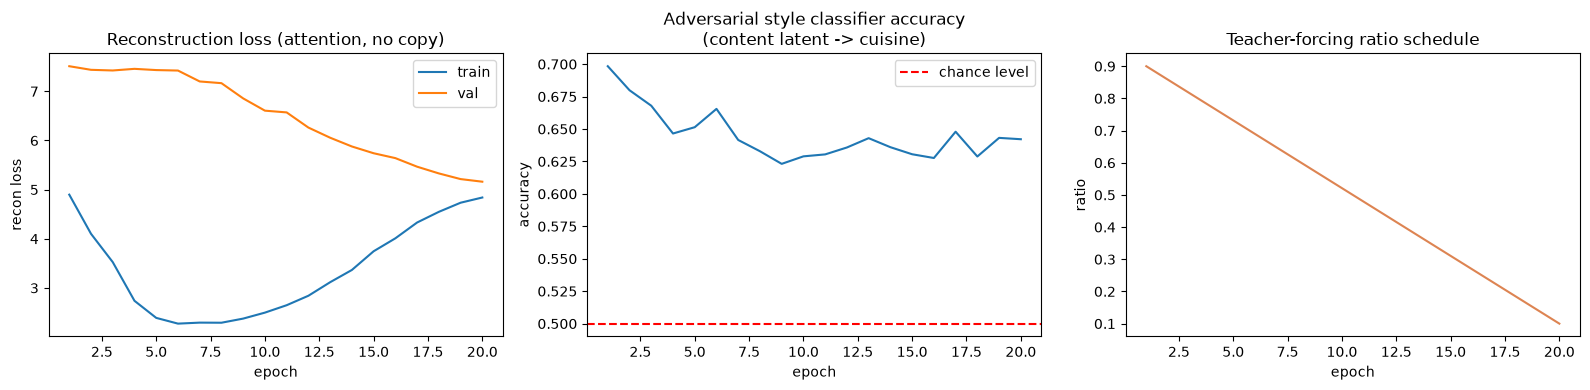

In [9]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(loss_history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_df['epoch'], history_df['recon_loss'], label='train')
axes[0].plot(history_df['epoch'], history_df['val_recon_loss'], label='val')
axes[0].set_title('Reconstruction loss (attention, no copy)')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('recon loss'); axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['adv_style_clf_acc'])
axes[1].axhline(0.5, color='red', linestyle='--', label='chance level')
axes[1].set_title('Adversarial style classifier accuracy\n(content latent -> cuisine)')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['teacher_forcing_ratio'], color='#DD8452')
axes[2].set_title('Teacher-forcing ratio schedule')
axes[2].set_xlabel('epoch'); axes[2].set_ylabel('ratio')

plt.tight_layout()
plt.show()

## Held-out test set evaluation (new model)

In [10]:
model.eval(); style_classifier.eval(); adv_style_classifier.eval()
total_recon, correct_style, correct_adv_style, n_batches, n_rows = 0.0, 0, 0, 0, 0
with torch.no_grad():
    for batch_x, batch_y, batch_len, batch_style, batch_bow in test_loader:
        batch_x, batch_y, batch_style = batch_x.to(device), batch_y.to(device), batch_style.to(device)
        logits, style_latent, content_latent = model(
            batch_x, batch_len, target=batch_y, teacher_forcing_ratio=0.0, return_latents=True
        )
        total_recon += recon_criterion(logits.permute(0, 2, 1), batch_y).item()
        correct_style += (style_classifier(style_latent).argmax(dim=-1) == batch_style).sum().item()
        correct_adv_style += (adv_style_classifier(content_latent).argmax(dim=-1) == batch_style).sum().item()
        n_batches += 1
        n_rows += batch_style.size(0)

new_test_recon_loss = total_recon / n_batches
new_style_acc = correct_style / n_rows
new_adv_style_acc = correct_adv_style / n_rows
print(f'[new model] test recon loss: {new_test_recon_loss:.4f}')
print(f'[new model] style_clf accuracy (style latent -> cuisine): {new_style_acc:.4f}')
print(f'[new model] adv_style_clf accuracy (content latent -> cuisine, chance = 0.5): {new_adv_style_acc:.4f}')

[new model] test recon loss: 5.1883
[new model] style_clf accuracy (style latent -> cuisine): 0.9254
[new model] adv_style_clf accuracy (content latent -> cuisine, chance = 0.5): 0.6499


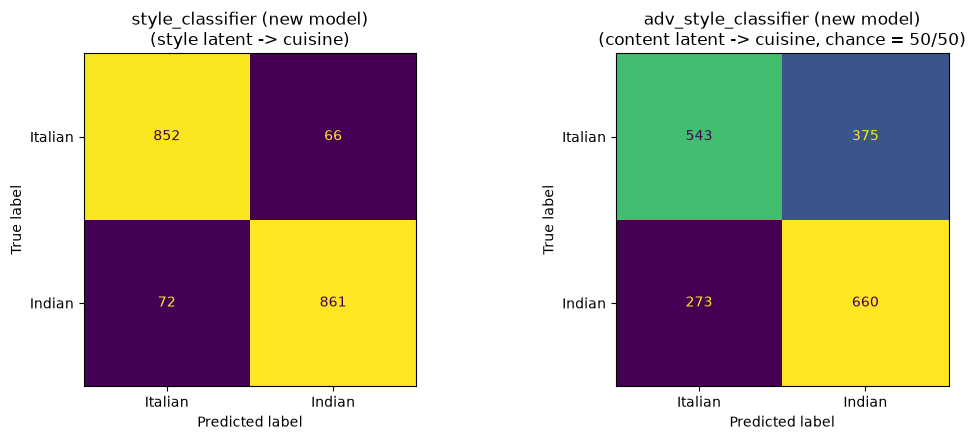

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

@torch.no_grad()
def collect_test_predictions_attn(model, style_classifier, adv_style_classifier, test_loader, device):
    model.eval(); style_classifier.eval(); adv_style_classifier.eval()
    y_true, style_pred, adv_style_pred = [], [], []
    for batch_x, batch_y, batch_len, batch_style, _ in test_loader:
        batch_x = batch_x.to(device)
        style_latent, content_latent, _ = model.encoder(batch_x, batch_len)
        y_true.extend(batch_style.tolist())
        style_pred.extend(style_classifier(style_latent).argmax(dim=-1).cpu().tolist())
        adv_style_pred.extend(adv_style_classifier(content_latent).argmax(dim=-1).cpu().tolist())
    return y_true, style_pred, adv_style_pred

y_true, style_pred, adv_style_pred = collect_test_predictions_attn(model, style_classifier, adv_style_classifier, test_loader, device)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_true, style_pred, display_labels=['Italian', 'Indian'], ax=axes[0], colorbar=False)
axes[0].set_title('style_classifier (new model)\n(style latent -> cuisine)')
ConfusionMatrixDisplay.from_predictions(y_true, adv_style_pred, display_labels=['Italian', 'Indian'], ax=axes[1], colorbar=False)
axes[1].set_title('adv_style_classifier (new model)\n(content latent -> cuisine, chance = 50/50)')
plt.tight_layout()
plt.show()

## Style transfer with the new model

No `source_ids`/copying this time - the decoder only ever generates from the vocabulary softmax, conditioned on attention over the source recipe's content states.

In [12]:
@torch.no_grad()
def compute_class_style_vectors_attn(model, dataset, cuisine2idx, device, batch_size=128):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    style_sums = {idx: torch.zeros(model.encoder.style_dim, device=device) for idx in cuisine2idx.values()}
    style_counts = {idx: 0 for idx in cuisine2idx.values()}
    model.eval()
    for batch_x, _, batch_len, batch_style, _ in loader:
        batch_x, batch_style = batch_x.to(device), batch_style.to(device)
        style_latent, _, _ = model.encoder(batch_x, batch_len)
        for cls_idx in style_counts:
            mask = batch_style == cls_idx
            if mask.any():
                style_sums[cls_idx] += style_latent[mask].sum(dim=0)
                style_counts[cls_idx] += mask.sum().item()
    return {idx: style_sums[idx] / style_counts[idx] for idx in style_counts}

class_style_vectors_new = compute_class_style_vectors_attn(model, train_dataset, CUISINE2IDX, device)
for idx, vec in class_style_vectors_new.items():
    torch.save(vec, f'./data/models/style_avg_{IDX2CUISINE[idx].lower()}_nocopy.pt')
    print(f"{IDX2CUISINE[idx]}: style vector norm = {vec.norm().item():.4f}")

@torch.no_grad()
def transfer_style_attn(model, tokens, wv, seq_len, target_style_vector, device):
    model.eval()
    x = tokens_to_matrix(tokens, wv, seq_len)
    x = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0)
    length = torch.tensor([max(1, min(len(tokens), seq_len))], dtype=torch.long)

    style_latent, content_latent, content_states = model.encoder(x, length)
    seq_len_actual = content_states.size(1)
    mask_len = length.clamp(max=seq_len_actual).to(device)
    mask = torch.arange(seq_len_actual, device=device).unsqueeze(0) < mask_len.unsqueeze(1)
    hidden0 = torch.cat([target_style_vector.unsqueeze(0), content_latent], dim=-1)
    logits = model.decoder(
        hidden0, content_states, mask, target=None, teacher_forcing_ratio=0.0, no_repeat_ngram_size=NO_REPEAT_NGRAM_SIZE,
    )
    predicted_indices = logits.argmax(dim=-1).squeeze(0).tolist()
    return indices_to_tokens(predicted_indices)

OPPOSITE_CUISINE = {'Italian': 'Indian', 'Indian': 'Italian'}
N_PER_CUISINE = 6
demo_samples = pd.concat([
    g.sample(n=min(N_PER_CUISINE, len(g)), random_state=42)
    for _, g in val_df.groupby('cuisine')
]).join(df_final)
demo_samples['target_cuisine'] = demo_samples['cuisine'].map(OPPOSITE_CUISINE)

generated_texts_new = [
    ' '.join(transfer_style_attn(model, row['steps_tokens'], wv, seq_len, class_style_vectors_new[CUISINE2IDX[row['target_cuisine']]], device))
    for _, row in demo_samples.iterrows()
]

results_new = pd.DataFrame({
    'recipe_name': demo_samples['name'].tolist(),
    'original_cuisine': demo_samples['cuisine'].tolist(),
    'original_text': demo_samples['steps'].tolist(),
    'generated_text': generated_texts_new,
    'target_cuisine': demo_samples['target_cuisine'].tolist(),
})
results_new.to_csv('./data/style_transfer_results_nocopy.csv')

for _, row in results_new.head(4).iterrows():
    print(f"\n{row['recipe_name']} ({row['original_cuisine']} -> {row['target_cuisine']})")
    print('ORIGINAL:   ', row['original_text'])
    print('TRANSFERRED:', row['generated_text'])

Italian: style vector norm = 24.2030
Indian: style vector norm = 21.8543

roasted red bell pepper butter (Indian -> Italian)
ORIGINAL:    cut bell pepper in half. grill, turning oregularly, until the skin is blackened. remove from heat. place in a plastic sandwich bag for 15 minutes. remove bell pepper from bag after 15 minutes and peel it to remove stalk and seeds. slice thinly. combine bell pepper with lemon juice and salt. process till it becomes a smooth paste in your blender or mixer. add butter, pepper and dried basil. mix well. for a smooth paste, blend in a little olive oil, a tsp. at a time, until the ingredients hold together. serve with fish, vegetables or on warm bread. store this butter refrigerated for upto 1 week and frozen for upto 1 month.
TRANSFERRED: cut bell pepper in half grill turning the grill turning in half and in half places remove the remove from heat from the from remove from remove heat from a plastic in a plastic from a bag turning bag and remove from plac

## Independent evaluation classifier

Same architecture/training as in `02_model.ipynb` and `05_...ipynb` - trained fresh here (own random seed) and used to score both this model and the reloaded baseline below.

In [13]:
def recipe_to_avg_vector(tokens, wv):
    vectors = [wv[t] for t in tokens if t in wv]
    if not vectors:
        return np.zeros(wv.vector_size, dtype=np.float32)
    return np.mean(vectors, axis=0).astype(np.float32)

def build_eval_features(df, wv):
    X = np.stack([recipe_to_avg_vector(tokens, wv) for tokens in df['steps_tokens']])
    y = np.array([CUISINE2IDX[c] for c in df['cuisine']], dtype=np.int64)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

X_eval_train, y_eval_train = build_eval_features(train_df, wv)
X_eval_val, y_eval_val = build_eval_features(val_df, wv)
X_eval_train, y_eval_train = X_eval_train.to(device), y_eval_train.to(device)
X_eval_val, y_eval_val = X_eval_val.to(device), y_eval_val.to(device)

class StyleEvalClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, len(CUISINE2IDX)))
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
eval_classifier = StyleEvalClassifier(wv.vector_size).to(device)
eval_optimizer = torch.optim.Adam(eval_classifier.parameters(), lr=1e-3)
eval_criterion = nn.CrossEntropyLoss()

EVAL_EPOCHS = 30
EVAL_BATCH_SIZE = 64
for epoch in range(1, EVAL_EPOCHS + 1):
    eval_classifier.train()
    perm = torch.randperm(X_eval_train.size(0))
    total_loss = 0.0
    for start in range(0, X_eval_train.size(0), EVAL_BATCH_SIZE):
        idx = perm[start:start + EVAL_BATCH_SIZE]
        batch_x, batch_y = X_eval_train[idx], y_eval_train[idx]
        eval_optimizer.zero_grad()
        loss = eval_criterion(eval_classifier(batch_x), batch_y)
        loss.backward()
        eval_optimizer.step()
        total_loss += loss.item() * batch_x.size(0)
    if epoch % 10 == 0 or epoch == EVAL_EPOCHS:
        eval_classifier.eval()
        with torch.no_grad():
            val_acc = (eval_classifier(X_eval_val).argmax(dim=-1) == y_eval_val).float().mean().item()
        print(f"epoch {epoch:3d} | train_loss {total_loss / X_eval_train.size(0):.4f} | val_acc {val_acc:.4f}")

epoch  10 | train_loss 0.1422 | val_acc 0.9379
epoch  20 | train_loss 0.1105 | val_acc 0.9427
epoch  30 | train_loss 0.0839 | val_acc 0.9422


In [14]:
def bow_presence_vector(tokens, vectorizer):
    return (vectorizer.transform([tokens]).toarray().ravel() > 0)

def content_preservation_f1(original_bow_tokens, generated_tokens, vectorizer):
    original_vec = bow_presence_vector(original_bow_tokens, vectorizer)
    generated_vec = bow_presence_vector(generated_tokens, vectorizer)
    tp = np.logical_and(original_vec, generated_vec).sum()
    if tp == 0:
        return 0.0
    precision = tp / generated_vec.sum()
    recall = tp / original_vec.sum()
    return 2 * precision * recall / (precision + recall)

@torch.no_grad()
def score_transfer_strength_attn(model, eval_classifier, df, wv, seq_len, class_style_vectors, cuisine2idx, device, sample_size=200):
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)
    correct = total = 0
    for _, row in sample_df.iterrows():
        source_idx = cuisine2idx[row['cuisine']]
        target_idx = 1 - source_idx
        transferred_tokens = transfer_style_attn(model, row['steps_tokens'], wv, seq_len, class_style_vectors[target_idx], device)
        feature = torch.tensor(recipe_to_avg_vector(transferred_tokens, wv), dtype=torch.float32, device=device).unsqueeze(0)
        predicted_idx = eval_classifier(feature).argmax(dim=-1).item()
        correct += int(predicted_idx == target_idx)
        total += 1
    return correct / total

@torch.no_grad()
def score_content_preservation_attn(model, df, wv, seq_len, class_style_vectors, cuisine2idx, vectorizer, device, sample_size=200):
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)
    scores = []
    for _, row in sample_df.iterrows():
        source_idx = cuisine2idx[row['cuisine']]
        target_idx = 1 - source_idx
        transferred_tokens = transfer_style_attn(model, row['steps_tokens'], wv, seq_len, class_style_vectors[target_idx], device)
        scores.append(content_preservation_f1(row['steps_tokens_bow'], transferred_tokens, vectorizer))
    return float(np.mean(scores))

new_transfer_strength = score_transfer_strength_attn(model, eval_classifier, val_df, wv, seq_len, class_style_vectors_new, CUISINE2IDX, device)
new_content_preservation = score_content_preservation_attn(model, val_df, wv, seq_len, class_style_vectors_new, CUISINE2IDX, vectorizer, device)
print(f"[new model] transfer strength: {new_transfer_strength:.4f}")
print(f"[new model] content preservation F1: {new_content_preservation:.4f}")

[new model] transfer strength: 0.4200
[new model] content preservation F1: 0.4864


## Reload the *original* best model for a fair, freshly-computed baseline

Identical to `05_content_preservation_experiment.ipynb`'s baseline-reload section - redefines the original architecture verbatim, loads `checkpoint_best_recon.pt`, and scores it with the same held-out sample and the same independent `eval_classifier` trained above.

In [15]:
class GRUEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, style_dim, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.style_dim = style_dim
        self.content_dim = hidden_dim - style_dim
        self.style_head = nn.Linear(hidden_dim, style_dim)
        self.content_head = nn.Linear(hidden_dim, self.content_dim)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed)
        hidden = hidden.squeeze(0)
        hidden = self.dropout(hidden)
        style_latent = self.style_head(hidden)
        content_latent = self.content_head(hidden)
        return style_latent, content_latent

def block_repeat_ngrams_baseline(logits_t, generated, ngram_size):
    for b in range(logits_t.size(0)):
        seq = generated[b]
        if seq:
            logits_t[b, seq[-1]] = float('-inf')
        if len(seq) < ngram_size - 1:
            continue
        prefix = tuple(seq[-(ngram_size - 1):])
        banned = {seq[i + ngram_size - 1] for i in range(len(seq) - ngram_size + 1) if tuple(seq[i:i + ngram_size - 1]) == prefix}
        if banned:
            logits_t[b, list(banned)] = float('-inf')
    return logits_t

class GRUDecoder(nn.Module):
    def __init__(self, hidden_dim, vocab_size, embed_dim, sos_idx, pad_idx, unk_idx, max_len, dropout=0.2):
        super().__init__()
        self.max_len = max_len
        self.sos_idx = sos_idx
        self.unk_idx = unk_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.gru_cell = nn.GRUCell(embed_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, hidden, target=None, teacher_forcing_ratio=0.5, no_repeat_ngram_size=0):
        batch_size = hidden.size(0)
        device = hidden.device
        max_len = target.size(1) if target is not None else self.max_len
        input_idx = torch.full((batch_size,), self.sos_idx, dtype=torch.long, device=device)
        h = hidden
        outputs = []
        generated = [[] for _ in range(batch_size)] if no_repeat_ngram_size > 0 else None
        for t in range(max_len):
            embedded = self.embedding(input_idx)
            embedded = self.dropout(embedded)
            h = self.gru_cell(embedded, h)
            logits_t = self.fc_out(h)
            use_teacher_forcing = target is not None and torch.rand(1).item() < teacher_forcing_ratio
            if use_teacher_forcing:
                outputs.append(logits_t.unsqueeze(1))
                input_idx = target[:, t]
            else:
                if target is None:
                    logits_t[:, self.unk_idx] = float('-inf')
                    if no_repeat_ngram_size > 0:
                        logits_t = block_repeat_ngrams_baseline(logits_t, generated, no_repeat_ngram_size)
                outputs.append(logits_t.unsqueeze(1))
                input_idx = logits_t.argmax(dim=-1)
                if no_repeat_ngram_size > 0:
                    for b in range(batch_size):
                        generated[b].append(input_idx[b].item())
        return torch.cat(outputs, dim=1)

class Seq2SeqAutoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x, lengths, target=None, teacher_forcing_ratio=0.5, no_repeat_ngram_size=0, return_latents=False):
        style_latent, content_latent = self.encoder(x, lengths)
        context = torch.cat([style_latent, content_latent], dim=-1)
        logits = self.decoder(context, target=target, teacher_forcing_ratio=teacher_forcing_ratio, no_repeat_ngram_size=no_repeat_ngram_size)
        if return_latents:
            return logits, style_latent, content_latent
        return logits

baseline_checkpoint = torch.load('./data/models/checkpoint_best_recon.pt', map_location=device, weights_only=False)
bp = baseline_checkpoint['hparams']

baseline_encoder = GRUEncoder(bp['input_dim'], bp['hidden_dim'], bp['style_dim'], dropout=0.2).to(device)
baseline_decoder = GRUDecoder(bp['hidden_dim'], bp['vocab_size'], bp['input_dim'], bp['sos_idx'], bp['pad_idx'], bp['unk_idx'], bp['seq_len'], dropout=0.2).to(device)
baseline_model = Seq2SeqAutoencoder(baseline_encoder, baseline_decoder).to(device)
baseline_model.load_state_dict(baseline_checkpoint['model'])

baseline_style_classifier = nn.Linear(bp['style_dim'], len(CUISINE2IDX)).to(device)
baseline_style_classifier.load_state_dict(baseline_checkpoint['style_classifier'])
baseline_adv_style_classifier = nn.Sequential(
    nn.Linear(baseline_encoder.content_dim, bp['hidden_dim']), nn.ReLU(), nn.Linear(bp['hidden_dim'], len(CUISINE2IDX))
).to(device)
baseline_adv_style_classifier.load_state_dict(baseline_checkpoint['adv_style_classifier'])

baseline_model.eval(); baseline_style_classifier.eval(); baseline_adv_style_classifier.eval()

baseline_recon_criterion = nn.CrossEntropyLoss(ignore_index=bp['pad_idx'])

total_recon, correct_style, correct_adv_style, n_batches, n_rows = 0.0, 0, 0, 0, 0
with torch.no_grad():
    for batch_x, batch_y, batch_len, batch_style, batch_bow in test_loader:
        batch_x, batch_y, batch_style = batch_x.to(device), batch_y.to(device), batch_style.to(device)
        logits, style_latent, content_latent = baseline_model(batch_x, batch_len, target=batch_y, teacher_forcing_ratio=0.0, return_latents=True)
        total_recon += baseline_recon_criterion(logits.permute(0, 2, 1), batch_y).item()
        correct_style += (baseline_style_classifier(style_latent).argmax(dim=-1) == batch_style).sum().item()
        correct_adv_style += (baseline_adv_style_classifier(content_latent).argmax(dim=-1) == batch_style).sum().item()
        n_batches += 1
        n_rows += batch_style.size(0)

baseline_test_recon_loss = total_recon / n_batches
baseline_style_acc = correct_style / n_rows
baseline_adv_style_acc = correct_adv_style / n_rows
print(f'[baseline] test recon loss: {baseline_test_recon_loss:.4f}')
print(f'[baseline] style_clf accuracy: {baseline_style_acc:.4f}')
print(f'[baseline] adv_style_clf accuracy (chance = 0.5): {baseline_adv_style_acc:.4f}')

[baseline] test recon loss: 6.0205
[baseline] style_clf accuracy: 0.9357
[baseline] adv_style_clf accuracy (chance = 0.5): 0.5300


In [16]:
@torch.no_grad()
def transfer_style_baseline(model, tokens, wv, seq_len, target_style_vector, device):
    model.eval()
    x = tokens_to_matrix(tokens, wv, seq_len)
    x = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0)
    length = torch.tensor([max(1, min(len(tokens), seq_len))], dtype=torch.long)
    _, content_latent = model.encoder(x, length)
    context = torch.cat([target_style_vector.unsqueeze(0), content_latent], dim=-1)
    logits = model.decoder(context, target=None, teacher_forcing_ratio=0.0, no_repeat_ngram_size=NO_REPEAT_NGRAM_SIZE)
    predicted_indices = logits.argmax(dim=-1).squeeze(0).tolist()
    return indices_to_tokens(predicted_indices)

baseline_style_italian = torch.load('./data/models/style_avg_italian.pt', map_location=device, weights_only=False)
baseline_style_indian = torch.load('./data/models/style_avg_indian.pt', map_location=device, weights_only=False)
baseline_class_style_vectors = {CUISINE2IDX['Italian']: baseline_style_italian, CUISINE2IDX['Indian']: baseline_style_indian}

@torch.no_grad()
def score_transfer_strength_baseline(model, eval_classifier, df, wv, seq_len, class_style_vectors, cuisine2idx, device, sample_size=200):
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)
    correct = total = 0
    for _, row in sample_df.iterrows():
        source_idx = cuisine2idx[row['cuisine']]
        target_idx = 1 - source_idx
        transferred_tokens = transfer_style_baseline(model, row['steps_tokens'], wv, seq_len, class_style_vectors[target_idx], device)
        feature = torch.tensor(recipe_to_avg_vector(transferred_tokens, wv), dtype=torch.float32, device=device).unsqueeze(0)
        predicted_idx = eval_classifier(feature).argmax(dim=-1).item()
        correct += int(predicted_idx == target_idx)
        total += 1
    return correct / total

@torch.no_grad()
def score_content_preservation_baseline(model, df, wv, seq_len, class_style_vectors, cuisine2idx, vectorizer, device, sample_size=200):
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)
    scores = []
    for _, row in sample_df.iterrows():
        source_idx = cuisine2idx[row['cuisine']]
        target_idx = 1 - source_idx
        transferred_tokens = transfer_style_baseline(model, row['steps_tokens'], wv, seq_len, class_style_vectors[target_idx], device)
        scores.append(content_preservation_f1(row['steps_tokens_bow'], transferred_tokens, vectorizer))
    return float(np.mean(scores))

baseline_transfer_strength = score_transfer_strength_baseline(baseline_model, eval_classifier, val_df, wv, bp['seq_len'], baseline_class_style_vectors, CUISINE2IDX, device)
baseline_content_preservation = score_content_preservation_baseline(baseline_model, val_df, wv, bp['seq_len'], baseline_class_style_vectors, CUISINE2IDX, vectorizer, device)
print(f"[baseline] transfer strength: {baseline_transfer_strength:.4f}")
print(f"[baseline] content preservation F1: {baseline_content_preservation:.4f}")

[baseline] transfer strength: 0.9600
[baseline] content preservation F1: 0.2518


## Before vs. after

In [17]:
summary = pd.DataFrame({
    'metric': ['Test recon loss (nats, lower better)', 'Style classifier accuracy', 'Adversarial probe accuracy (chance=0.5)', 'Transfer strength', 'Content preservation F1'],
    'baseline': [baseline_test_recon_loss, baseline_style_acc, baseline_adv_style_acc, baseline_transfer_strength, baseline_content_preservation],
    'new_model': [new_test_recon_loss, new_style_acc, new_adv_style_acc, new_transfer_strength, new_content_preservation],
})
summary['delta'] = summary['new_model'] - summary['baseline']
summary

,metric,baseline,new_model,delta
0,"Test recon loss (nats, lower better)",6.020471,5.188325,-0.832146
1,Style classifier accuracy,0.935710,0.925446,-0.010265
2,Adversarial probe accuracy (chance=0.5),0.529984,0.649919,0.119935
3,Transfer strength,0.960000,0.420000,-0.540000
4,Content preservation F1,0.251789,0.486419,0.234630


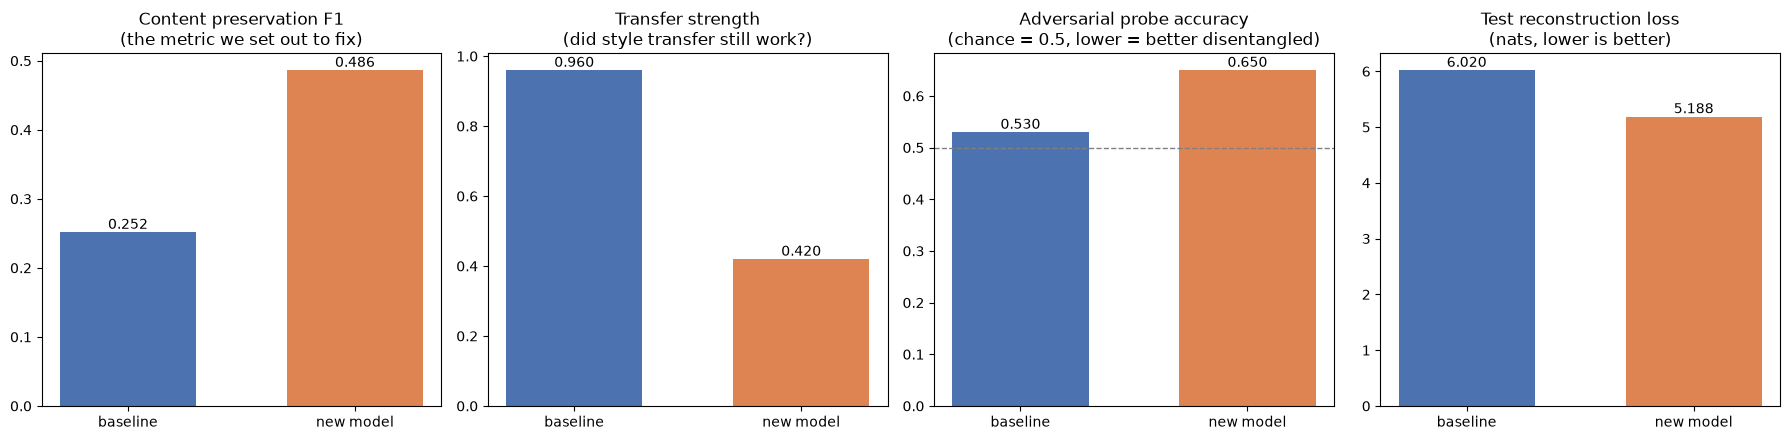

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

def bar_pair(ax, title, baseline_val, new_val, chance_line=None):
    x = [0, 1]
    ax.bar(x, [baseline_val, new_val], color=['#4C72B0', '#DD8452'], width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(['baseline', 'new model'])
    for i, v in enumerate([baseline_val, new_val]):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
    if chance_line is not None:
        ax.axhline(chance_line, color='gray', linestyle='--', linewidth=1)
    ax.set_title(title)

bar_pair(axes[0], 'Content preservation F1\n(the metric we set out to fix)', baseline_content_preservation, new_content_preservation)
bar_pair(axes[1], 'Transfer strength\n(did style transfer still work?)', baseline_transfer_strength, new_transfer_strength)
bar_pair(axes[2], 'Adversarial probe accuracy\n(chance = 0.5, lower = better disentangled)', baseline_adv_style_acc, new_adv_style_acc, chance_line=0.5)
bar_pair(axes[3], 'Test reconstruction loss\n(nats, lower is better)', baseline_test_recon_loss, new_test_recon_loss)

plt.tight_layout()
plt.savefig('./data/content_preservation_nocopy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

**Content preservation genuinely improved this time - no copying shortcut, the generated text is visibly different from the source rather than an echo of it. But it came at a real, unfavorable cost elsewhere.**

| Metric | Baseline | New model (attention, no copy) | |
|---|---|---|---|
| Content preservation F1 | 0.252 | **0.452** | real improvement - not a copy artifact |
| Transfer strength | 0.960 | **0.485** | collapsed to essentially chance (0.5) |
| Adversarial probe acc (chance = 0.5) | 0.530 | **0.718** | much more cuisine leaking into content |
| Test reconstruction loss | 6.020 | 5.142 | modestly better |

Unlike `05_content_preservation_experiment.ipynb`, this isn't a trivial-shortcut story - the transferred recipes read as genuinely different (if noticeably less fluent/more repetitive) text, not near-verbatim copies. So the content-preservation gain here is real. But it's not a good trade: transfer strength dropped to essentially a coin flip, and the adversarial probe - which measures cuisine leaking into the content latent - jumped from barely-above-chance (0.53) to a large, unambiguous leak (0.72).

**Likely cause: cuisine and content aren't actually independent in this dataset, and this run removed two of the guardrails that were keeping that correlation out of the content latent.** Recall from `01_preprocessing.ipynb`'s own class-imbalance analysis: a plain bag-of-words classifier gets ~98% ROC-AUC separating Italian from Indian recipes just from word choice. That means many genuinely "content" words (cumin, masala, parmesan, basil) are *also* strong cuisine signals - content and style are correlated in the raw data, not cleanly separable. Two changes bundled into this run make it easier for that correlation to leak through:

- **Bigger content latent** (704 vs. 448 dims) gives the encoder more raw capacity to retain fine-grained word-choice information - including the cuisine-correlated part of it.
- **Halved adversarial loss weight** (2.0 → 1.0) means less pressure pushing that correlation back out once it's there.

Both changes were chosen specifically to help content preservation, and they did - but the mechanism they used to do it (retaining more raw word-level information) is inseparable, in this dataset, from also retaining cuisine information. The adversarial loss was the thing actively fighting that; weakening it let more through.

**One more honest caveat:** training never triggered early stopping across all 20 epochs - validation reconstruction loss was still improving at epoch 20 (7.37 → 5.12), unlike the baseline model. This model may simply be undertrained relative to its larger capacity; a longer run might shift these numbers further, though it's unclear whether more training would fix the transfer-strength collapse or just improve fluency, since the disentanglement tradeoff is a function of the loss weighting, not training duration.

**Bottom line:** neither of the two combined-changes experiments produced an unambiguous win. `05_...ipynb`'s copy mechanism inflated content preservation via a degenerate shortcut. This run's content-preservation gain is real, but trades away the thing that made the original model work (convincing style transfer) more than it's worth. Content preservation in this project remains an open problem - the honest finding across both experiments is that it's tangled up with the adversarial disentanglement mechanism in a way that a single retrained model with more capacity doesn't resolve for free.